In [1]:
%pip install music21

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.signal import medfilt
from collections import Counter
from scipy.ndimage import median_filter
import music21

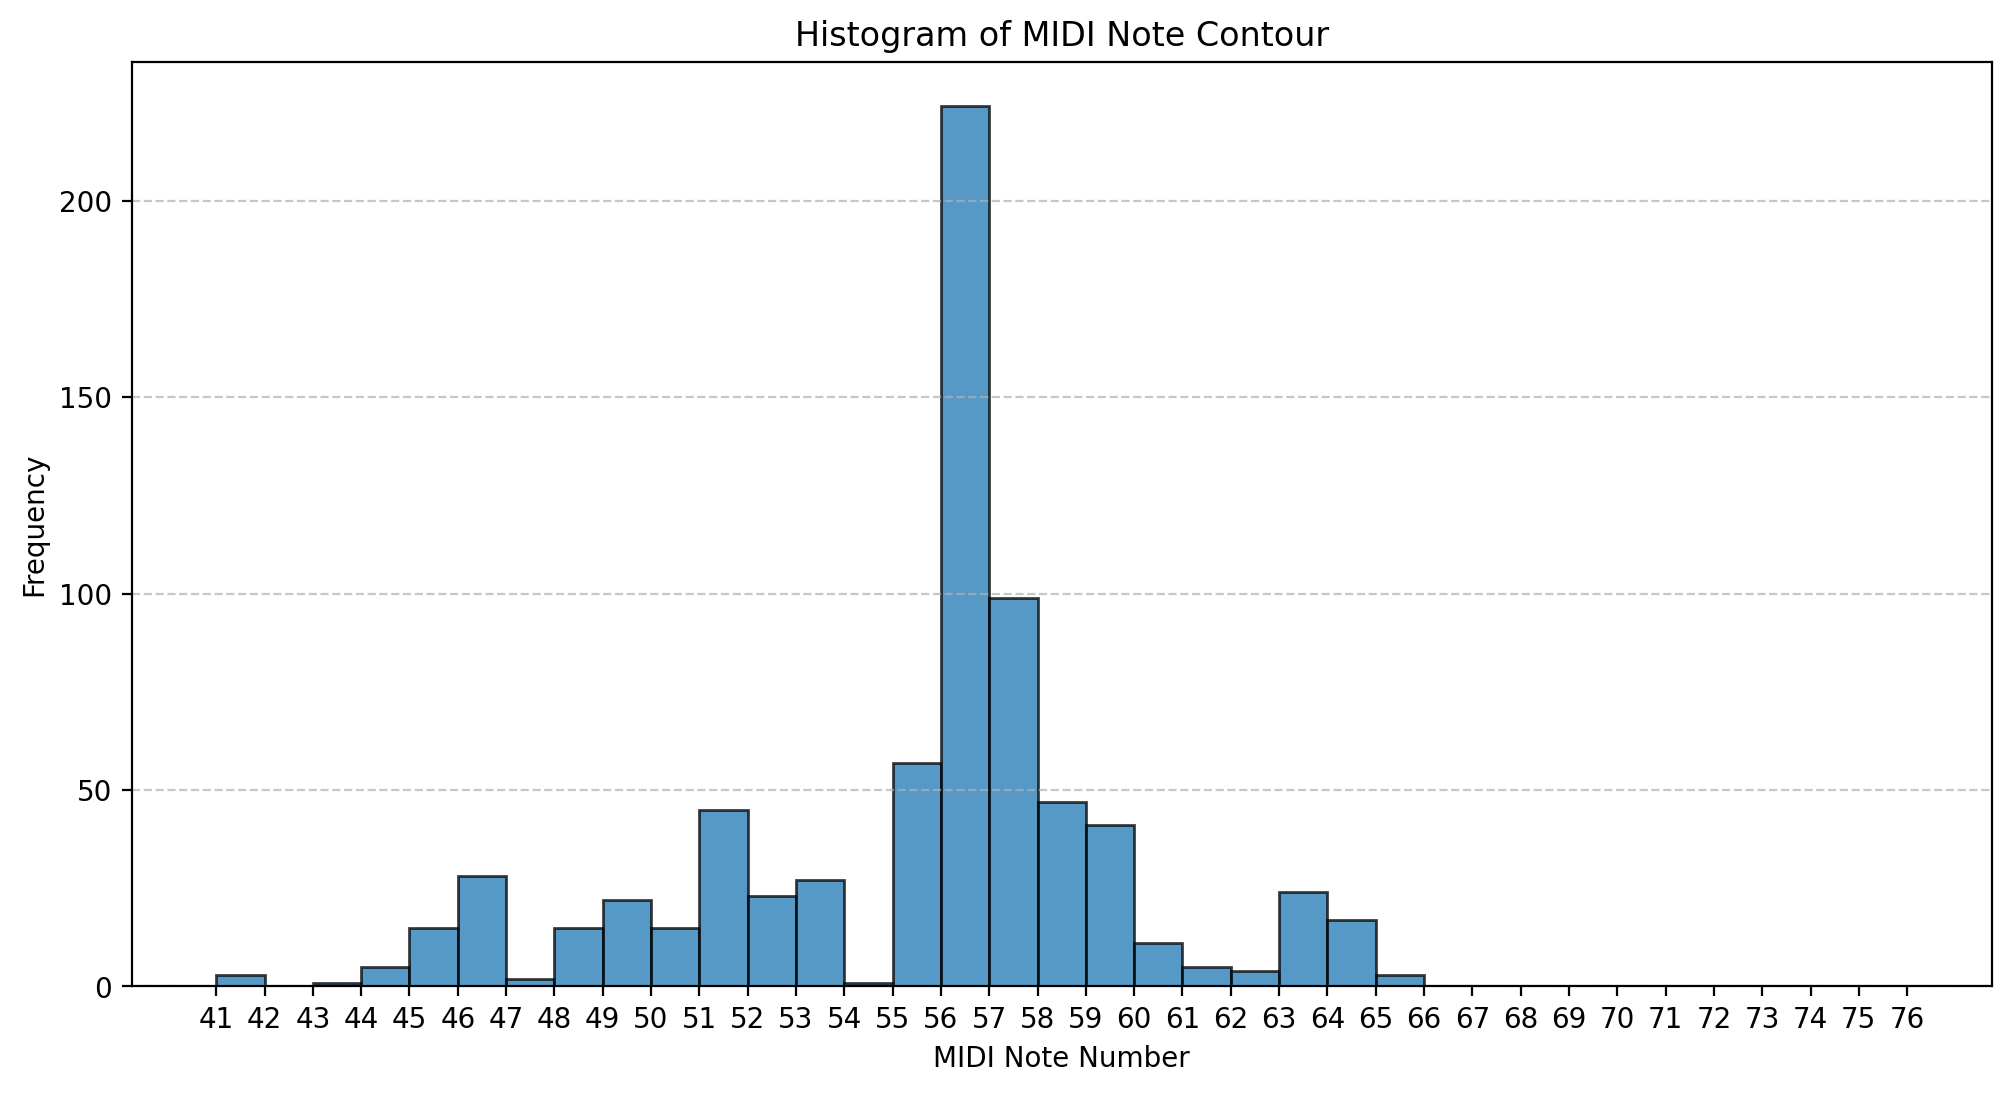

In [ ]:
def frequency_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

def get_midi_contour_from_csv(csv_fn, low_pitch=41, high_pitch=77):
    df = pd.read_csv(csv_fn)
    df.columns = ["time", "frequency", "confidence"]
    frequency = df['frequency'].values
    confidence = df['confidence'].values
    threshold = 0.7
    frequency[confidence < threshold] = np.nan
    filtered_frequency = median_filter(frequency, size = 5, mode = 'nearest')

    pitch_in_midi = [frequency_to_midi(freq) for freq in filtered_frequency]
    midi_notes =[x for x in pitch_in_midi if low_pitch <= x < high_pitch]
    return midi_notes

file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0/박봉술 춘향가 천자뒤풀이 김명환_2_Ujo.csv'

midi_notes = get_midi_contour_from_csv(file_path)

unique_midi_numbers = sorted(set(midi_notes))

plt.figure(figsize=(12, 6))
plt.hist(midi_notes, bins=np.arange(41, 77), edgecolor='black', alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("Histogram of MIDI Note Contour")
plt.xticks(np.arange(41, 77))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def extract_midi_pitches_from_musicxml(xml_path):
    score = music21.converter.parse(xml_path)
    midi_pitches = []

    for note in score.recurse().notes:
        if isinstance(note, music21.note.Note):
            midi_pitches.append(note.pitch.midi)

    return midi_pitches

# 군사 설움 타령 아내 생각 

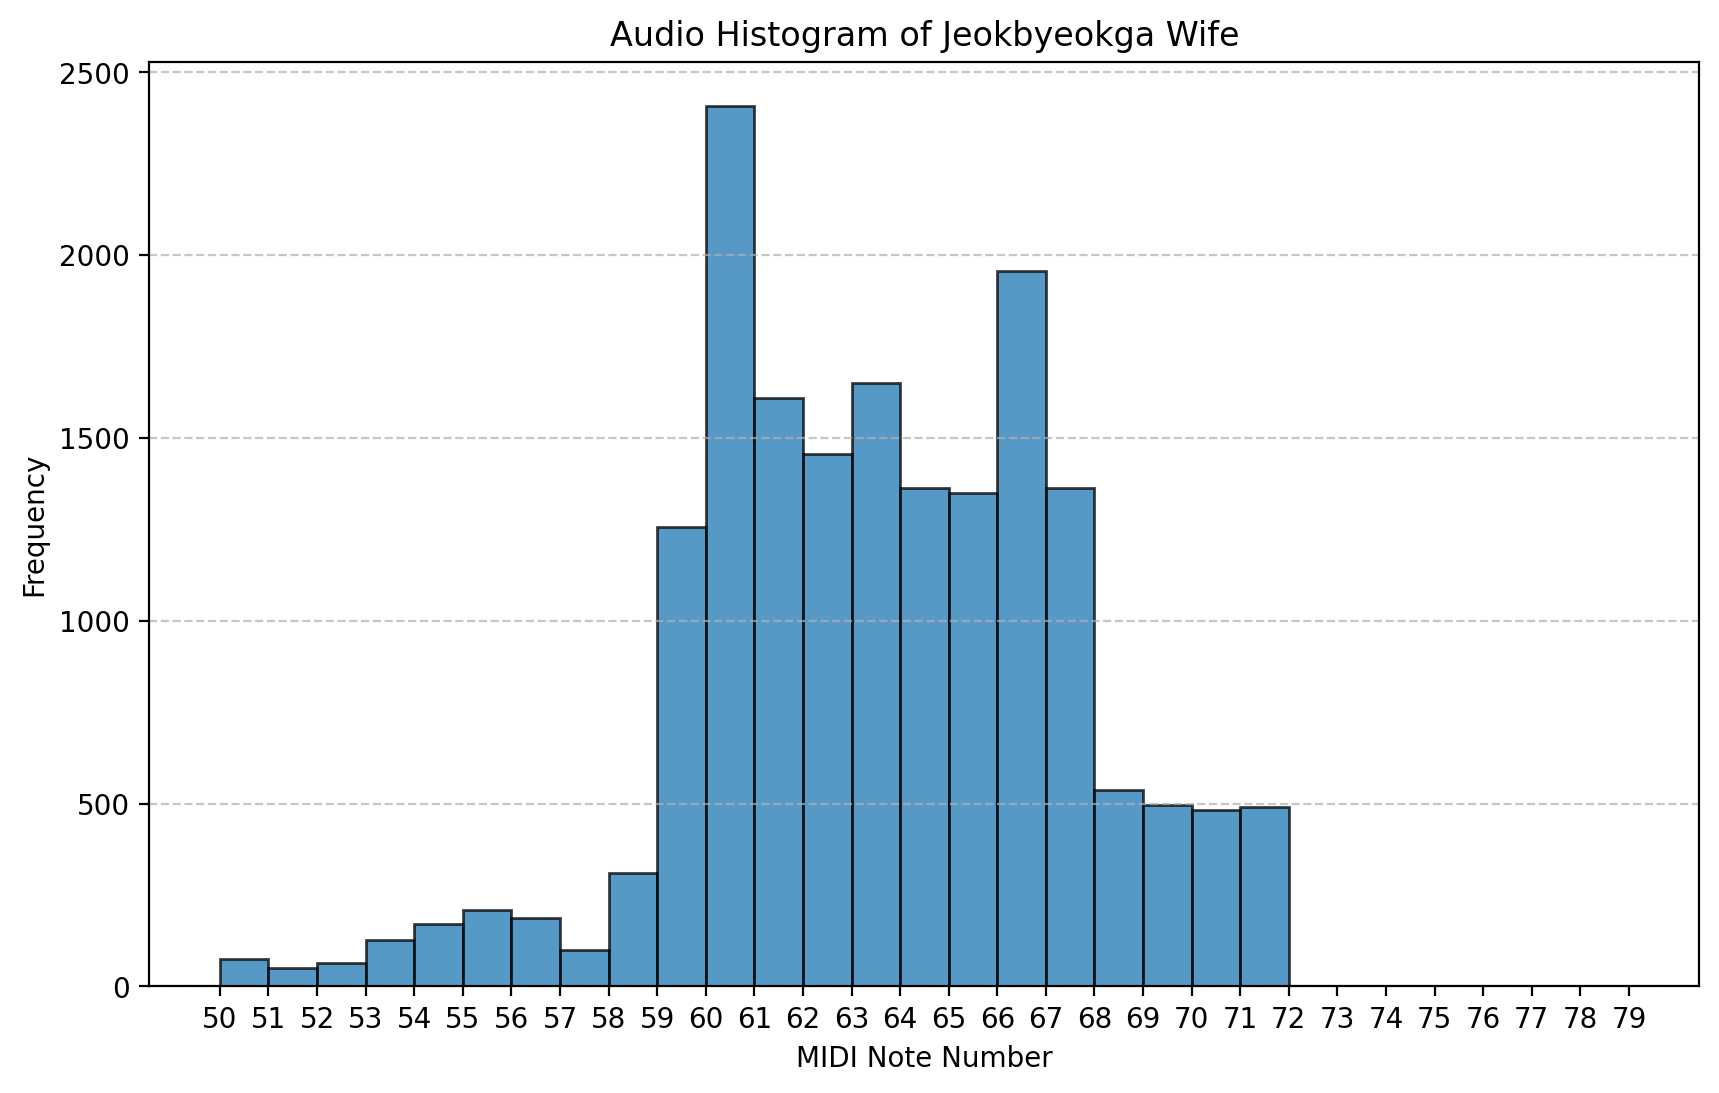

In [41]:
file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/군사 설움 타령 아내 생각 중머리.csv'

midi_notes = get_midi_contour_from_csv(file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_notes, bins=np.arange(50, 80), edgecolor='black', alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("Audio Histogram of Jeokbyeokga Wife")
plt.xticks(np.arange(50, 80))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

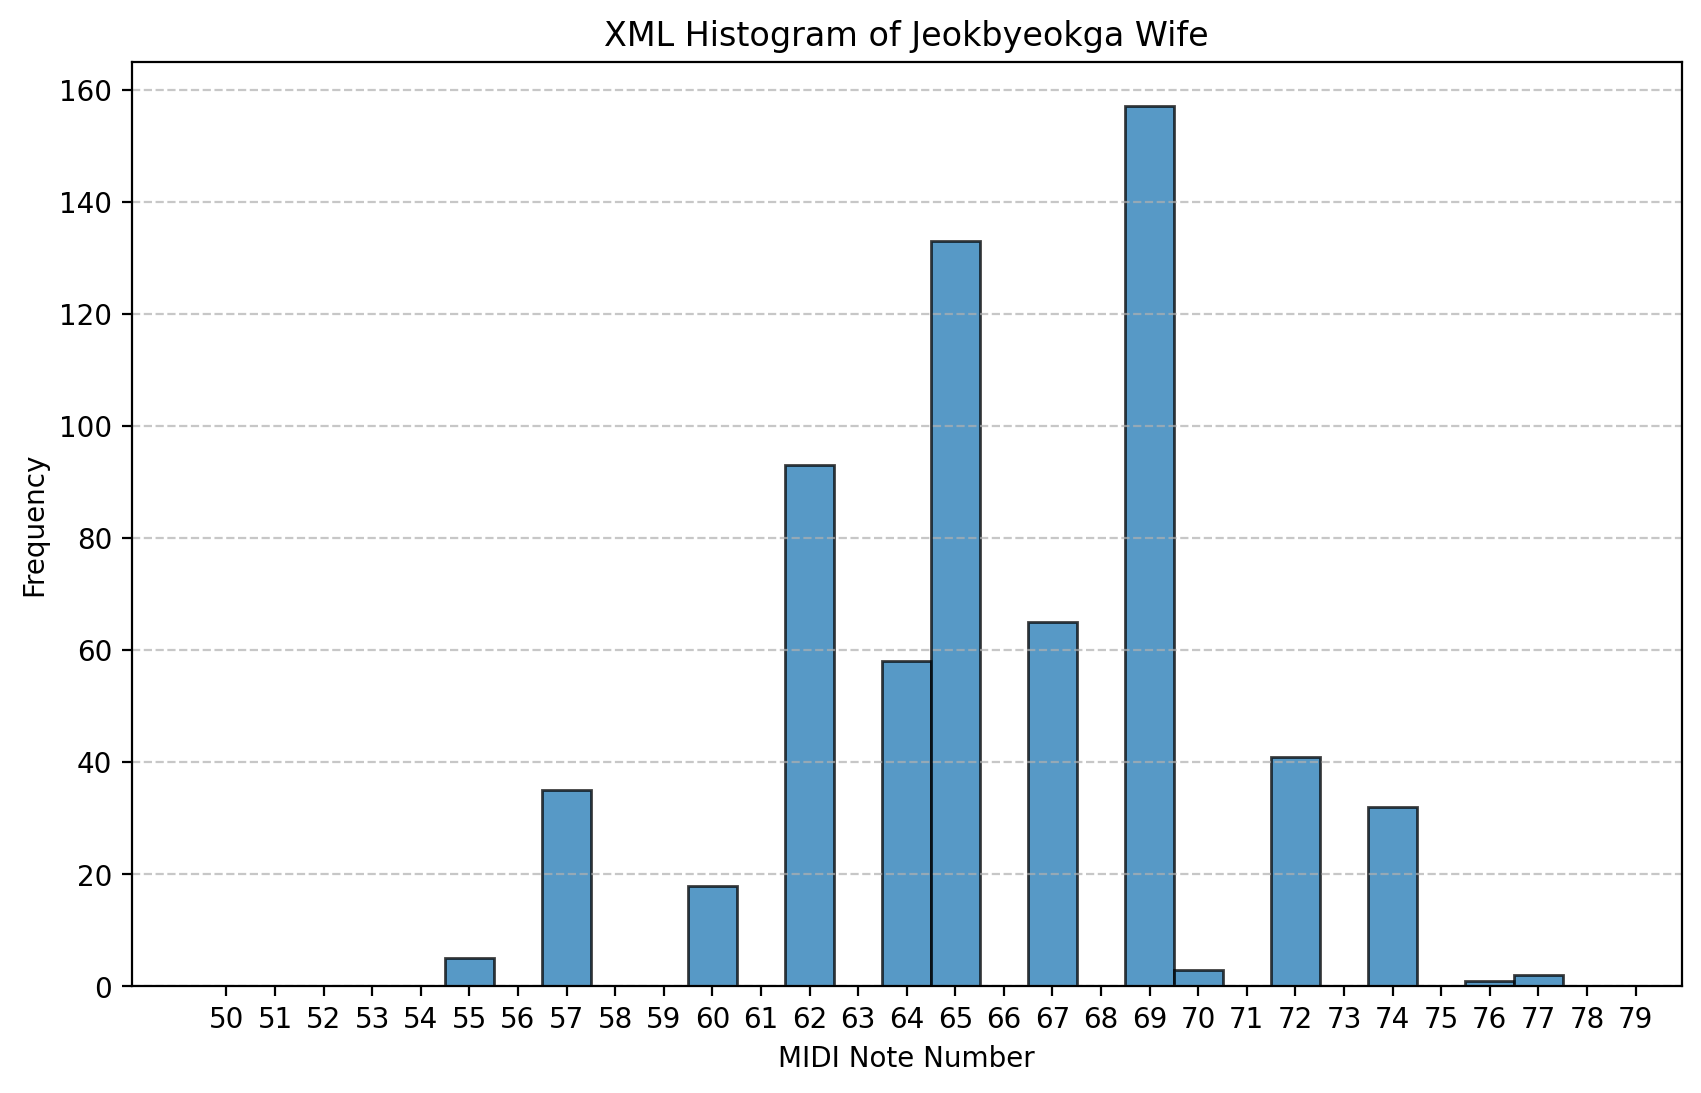

In [37]:
xml_file_path = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/11-3-a.musicxml"

midi_pitches = extract_midi_pitches_from_musicxml(xml_file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_pitches, bins=np.arange(50, 80) - 0.5, edgecolor="black", alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("XML Histogram of Jeokbyeokga Wife")
plt.xticks(np.arange(50, 80))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 정욱과 조조 군사 탄식 

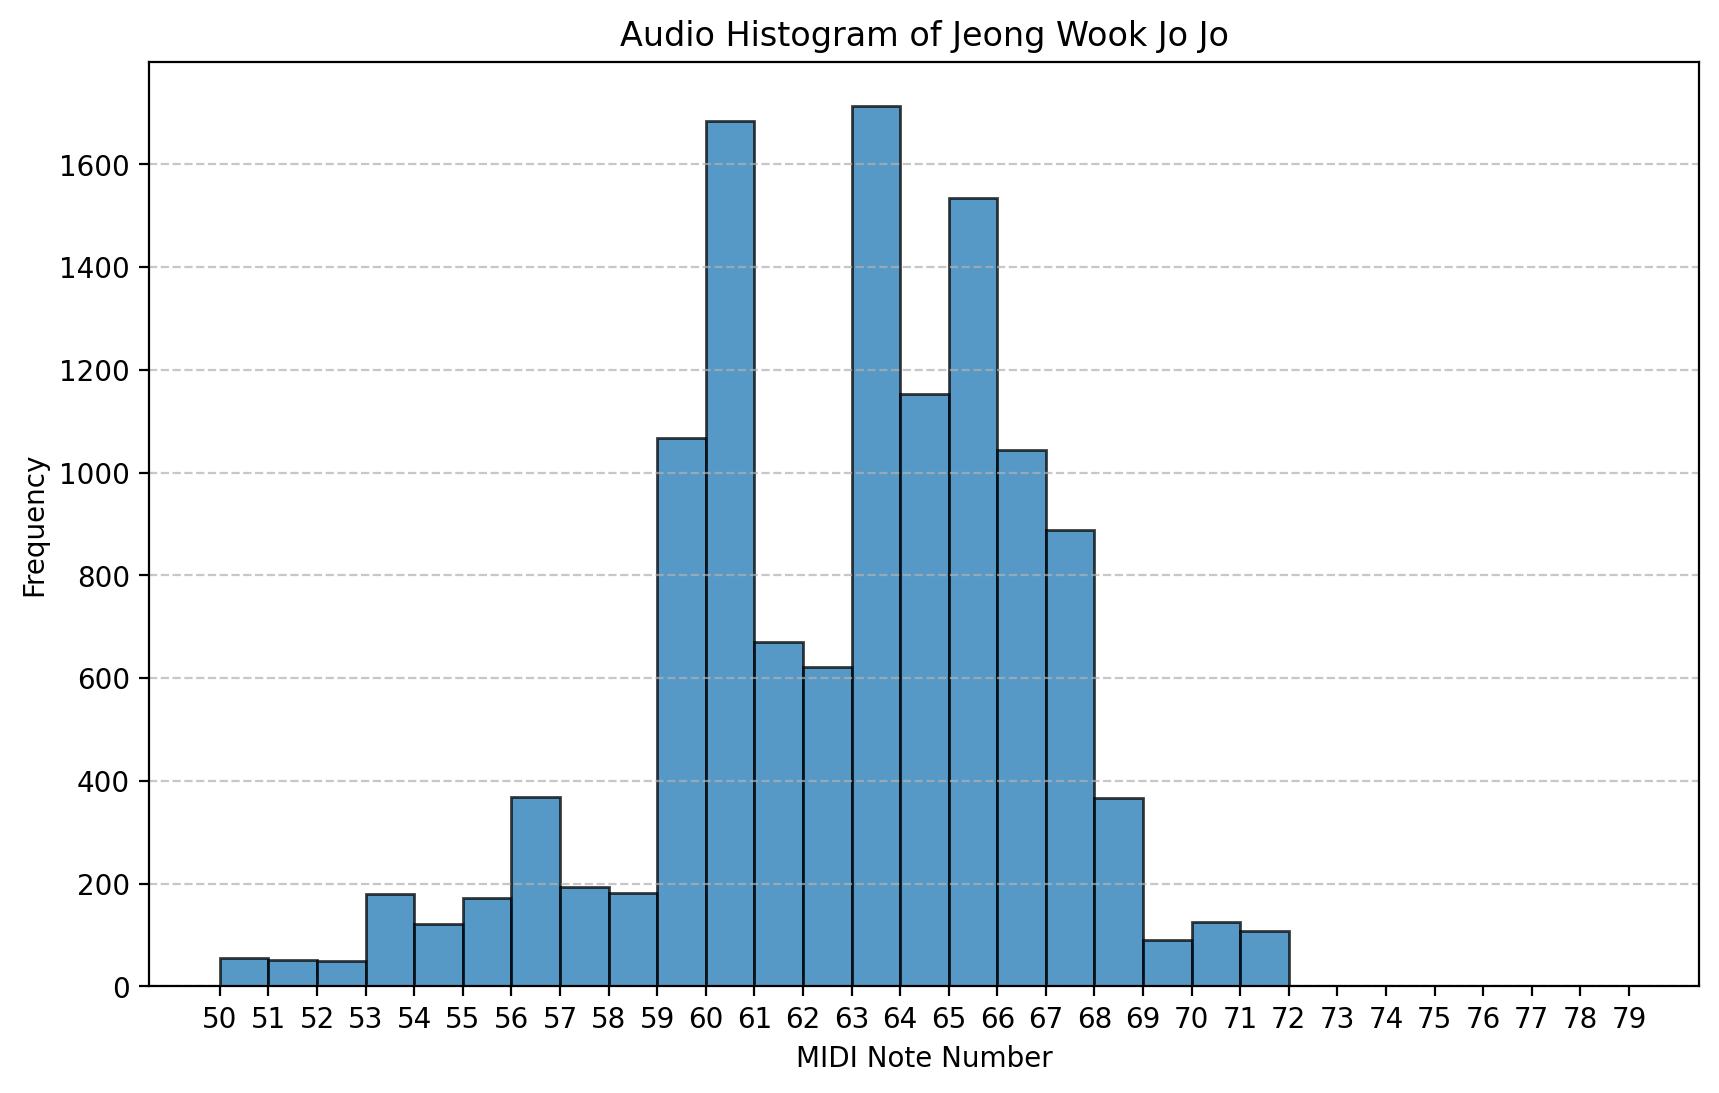

In [35]:
file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/정욱과 조조 군사 탄식 중머리.csv'

midi_notes = get_midi_contour_from_csv(file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_notes, bins=np.arange(50, 80), edgecolor='black', alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("Audio Histogram of Jeong Wook Jo Jo")
plt.xticks(np.arange(50, 80))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

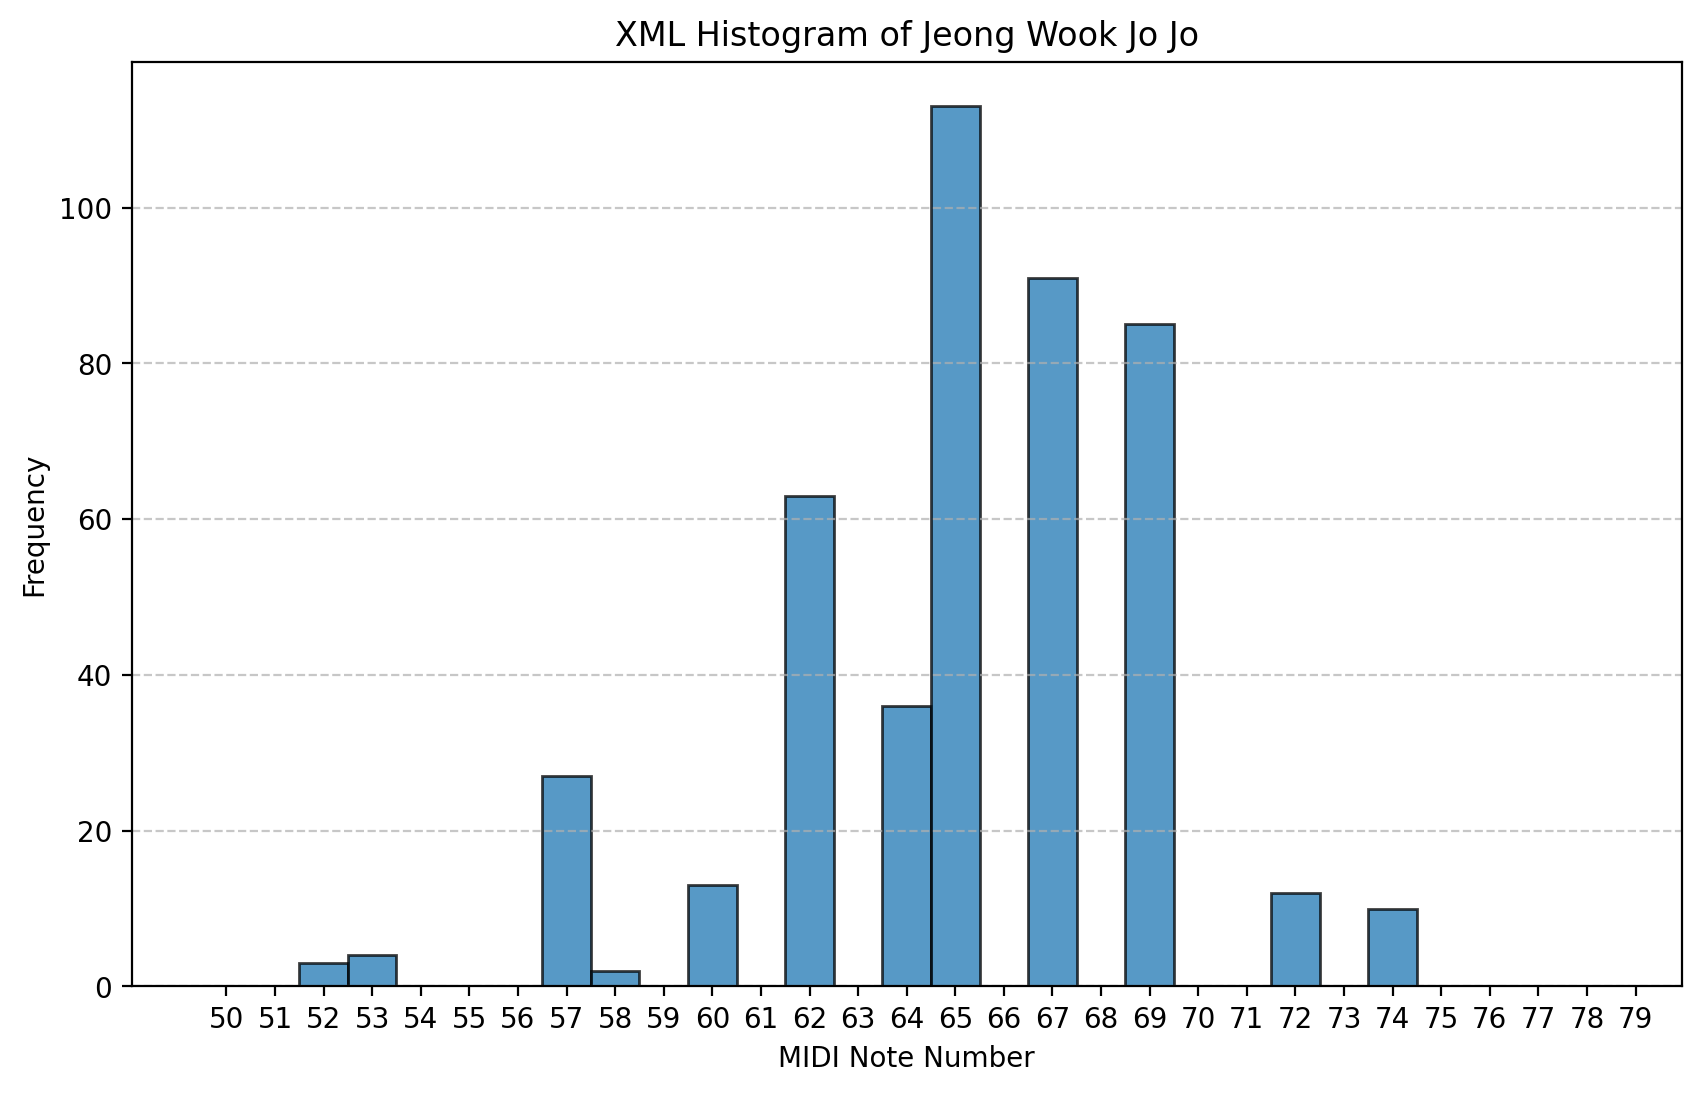

In [32]:
xml_file_path = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/28-1.musicxml"

midi_pitches = extract_midi_pitches_from_musicxml(xml_file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_pitches, bins=np.arange(50, 80) - 0.5, edgecolor="black", alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("XML Histogram of Jeong Wook Jo Jo")
plt.xticks(np.arange(50, 80))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 조조 군사 점고 

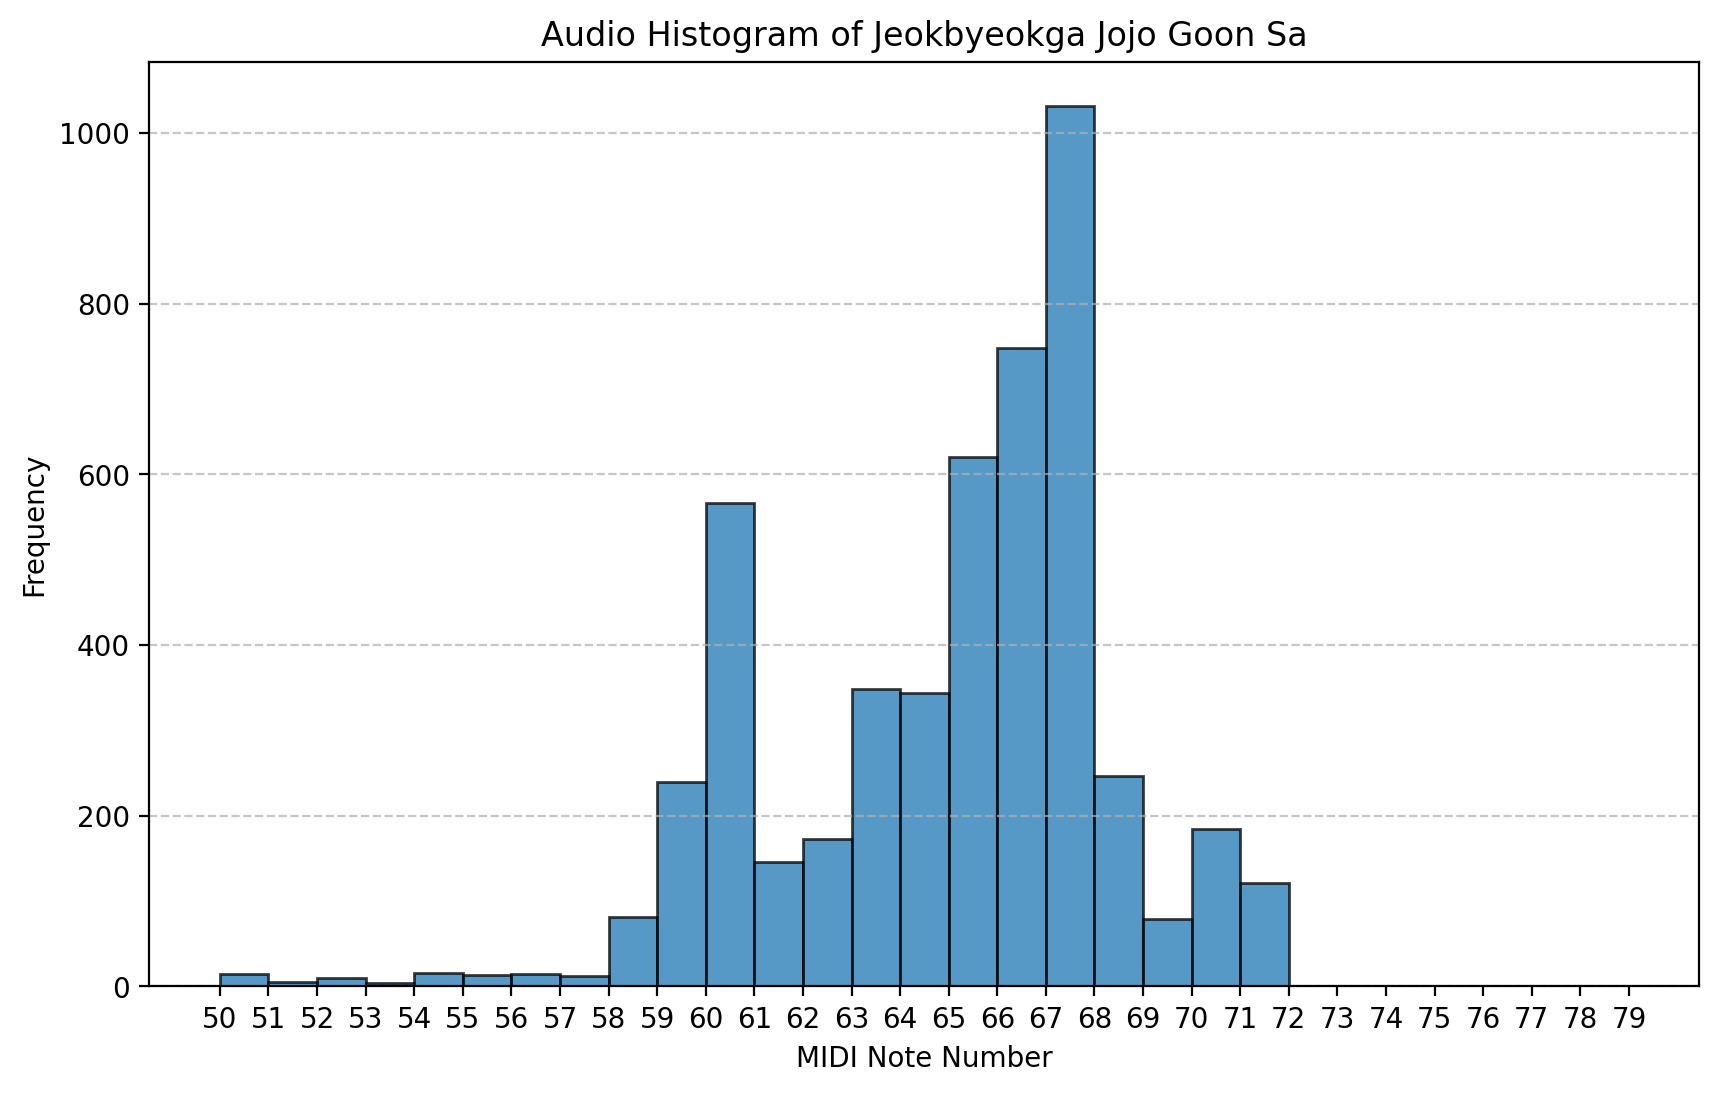

In [33]:
file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/조조 군사 점고 골래종이전동다리구먹쇠 자진머리.csv'

midi_notes = get_midi_contour_from_csv(file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_notes, bins=np.arange(50, 80), edgecolor='black', alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("Audio Histogram of Jeokbyeokga Jojo Goon Sa")
plt.xticks(np.arange(50, 80))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

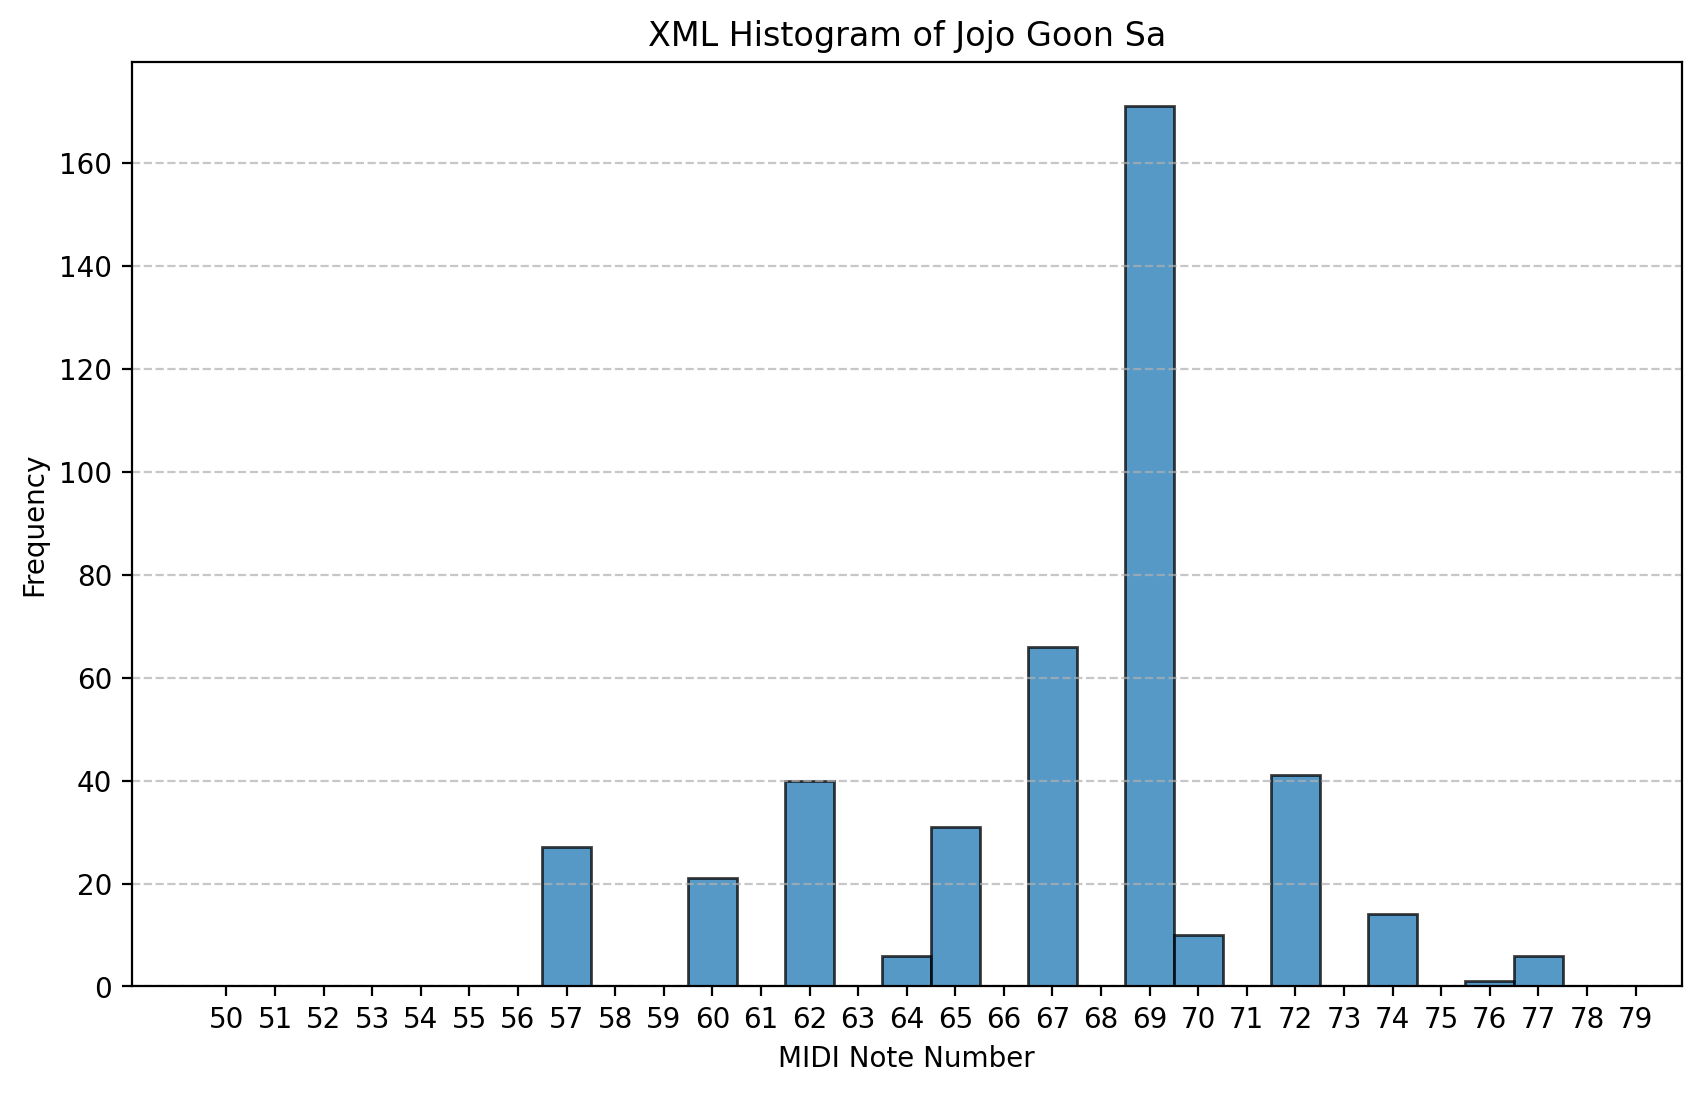

In [34]:
xml_file_path = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/31-4.musicxml"

midi_pitches = extract_midi_pitches_from_musicxml(xml_file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_pitches, bins=np.arange(50, 80) - 0.5, edgecolor="black", alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("XML Histogram of Jojo Goon Sa")
plt.xticks(np.arange(50, 80))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


